In [33]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorboard.backend.event_processing import event_accumulator

In [34]:
LOG_ROOT = Path("runs")

TAGS = [
    "custom/timesteps_vs_event_progress",
    "custom/wall_clock_vs_event_progress",
    "custom/llm_queries_vs_event_progress",
]

TAG_TO_XNAME = {
    "custom/timesteps_vs_event_progress": "timesteps",
    "custom/wall_clock_vs_event_progress": "wall_clock_seconds",
    "custom/llm_queries_vs_event_progress": "llm_queries",
}

In [35]:
def load_scalar_events_from_dir(run_dir: Path, tags=TAGS):
    """
    Read all tfevents files in one run directory and return a tidy dataframe.
    """
    rows = []

    event_files = sorted(run_dir.glob("events.out.tfevents.*"))
    if not event_files:
        return pd.DataFrame()

    for event_file in event_files:
        try:
            ea = event_accumulator.EventAccumulator(
                str(event_file),
                size_guidance={"scalars": 0},
            )
            ea.Reload()
        except Exception as e:
            print(f"Skipping {event_file} because {e}")
            continue

        available_tags = ea.Tags().get("scalars", [])
        for tag in tags:
            if tag not in available_tags:
                continue

            x_name = TAG_TO_XNAME[tag]
            events = ea.Scalars(tag)

            for ev in events:
                rows.append({
                    "agent": run_dir.name,
                    "event_file": event_file.name,
                    "tag": tag,
                    "x_name": x_name,
                    "x": ev.step,
                    "event_progress": ev.value,
                    "tb_step": ev.step,   # same here because you used custom scalar step directly
                })

    df = pd.DataFrame(rows)

    if df.empty:
        return df

    # Drop exact duplicates that can happen across files
    df = df.drop_duplicates(subset=["agent", "tag", "x", "event_progress"])
    return df

In [36]:
all_dfs = []
for run_dir in sorted(LOG_ROOT.iterdir()):
    if run_dir.is_dir():
        df_run = load_scalar_events_from_dir(run_dir)
        if not df_run.empty:
            all_dfs.append(df_run)

df = pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()
df.head()

,agent,event_file,tag,x_name,x,event_progress,tb_step
0,llm_without_thinking_32b,events.out.tfevents.1776599154.JaredsDesktop.2...,custom/timesteps_vs_event_progress,timesteps,250,0.0,250
1,llm_without_thinking_32b,events.out.tfevents.1776599154.JaredsDesktop.2...,custom/timesteps_vs_event_progress,timesteps,500,0.0,500
2,llm_without_thinking_32b,events.out.tfevents.1776599154.JaredsDesktop.2...,custom/timesteps_vs_event_progress,timesteps,750,0.0,750
3,llm_without_thinking_32b,events.out.tfevents.1776599154.JaredsDesktop.2...,custom/timesteps_vs_event_progress,timesteps,1000,0.0,1000
4,llm_without_thinking_32b,events.out.tfevents.1776599154.JaredsDesktop.2...,custom/timesteps_vs_event_progress,timesteps,1250,0.0,1250


In [37]:
df["agent"].unique()

array(['llm_without_thinking_32b', 'llm_without_thinking_8b',
       'vanilla_ppo_1'], dtype=object)

In [ ]:
def plot_metric(df, x_name, title=None, save_path=None):
    sub = df[df["x_name"] == x_name].copy()
    if sub.empty:
        print(f"No data for {x_name}")
        return

    plt.figure(figsize=(9, 5))

    for agent, g in sub.groupby("agent"):
        g = g.sort_values("x")

        g_mean = (
            g.groupby("x", as_index=False)["event_progress"]
             .mean()
             .sort_values("x")
        )

        plt.plot(g_mean["x"], g_mean["event_progress"], label=agent)

    plt.xlabel(x_name.replace("_", " ").title())
    plt.ylabel("Event progress")
    plt.title(title or f"Event Progress vs {x_name}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 👇 ONLY apply to wall clock
    if x_name == "wall_clock_seconds":
        plt.xlim(0, 11000)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

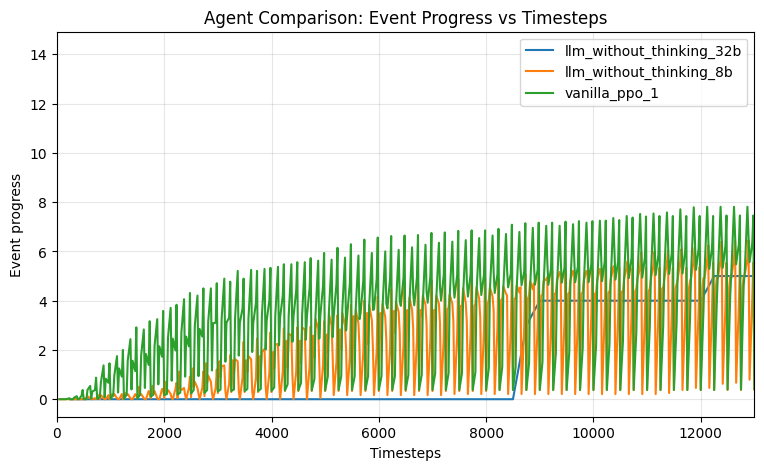

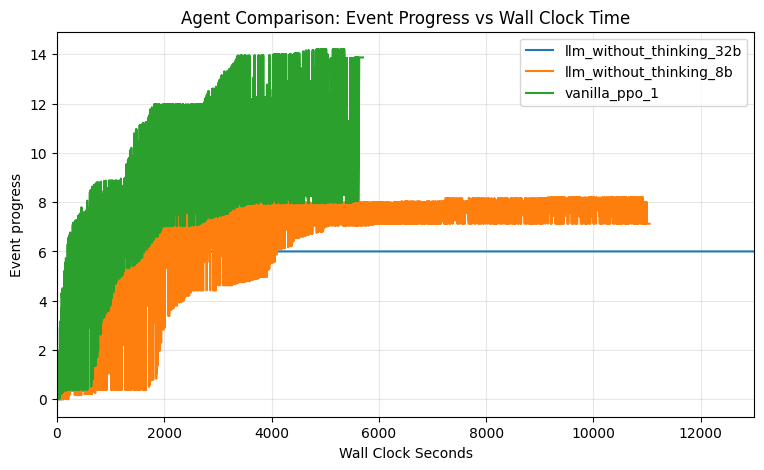

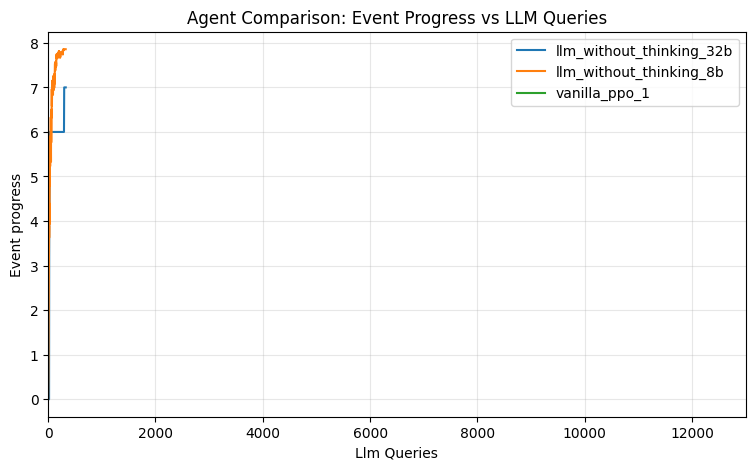

In [39]:
from pathlib import Path
Path("figures").mkdir(exist_ok=True)

plot_metric(df, "timesteps",
            "Agent Comparison: Event Progress vs Timesteps",
            save_path="figures/event_progress_vs_timesteps.png")

plot_metric(df, "wall_clock_seconds",
            "Agent Comparison: Event Progress vs Wall Clock Time",
            save_path="figures/event_progress_vs_wall_clock.png")

plot_metric(df, "llm_queries",
            "Agent Comparison: Event Progress vs LLM Queries",
            save_path="figures/event_progress_vs_llm_queries.png")

In [32]:
def summarize_agents(df):
    summaries = []

    for agent, g in df.groupby("agent"):
        g_time = df[(df["agent"] == agent) & (df["x_name"] == "timesteps")].copy()
        g_wall = df[(df["agent"] == agent) & (df["x_name"] == "wall_clock_seconds")].copy()
        g_llm  = df[(df["agent"] == agent) & (df["x_name"] == "llm_queries")].copy()

        # Average duplicates by x first
        def prep(sub):
            if sub.empty:
                return sub
            return (
                sub.groupby("x", as_index=False)["event_progress"]
                   .mean()
                   .sort_values("x")
            )

        g_time = prep(g_time)
        g_wall = prep(g_wall)
        g_llm = prep(g_llm)

        max_prog = np.nan
        first_timestep_at_max = np.nan
        first_wall_at_max = np.nan
        first_llm_at_max = np.nan

        if not g_time.empty:
            max_prog = g_time["event_progress"].max()
            first_timestep_at_max = g_time.loc[
                g_time["event_progress"].ge(max_prog), "x"
            ].iloc[0]

        if not g_wall.empty and not np.isnan(max_prog):
            wall_match = g_wall[g_wall["event_progress"].ge(max_prog)]
            if not wall_match.empty:
                first_wall_at_max = wall_match["x"].iloc[0]

        if not g_llm.empty and not np.isnan(max_prog):
            llm_match = g_llm[g_llm["event_progress"].ge(max_prog)]
            if not llm_match.empty:
                first_llm_at_max = llm_match["x"].iloc[0]

        summaries.append({
            "agent": agent,
            "max_event_progress": max_prog,
            "timesteps_to_max": first_timestep_at_max,
            "wall_clock_seconds_to_max": first_wall_at_max,
            "llm_queries_to_max": first_llm_at_max,
        })

    return pd.DataFrame(summaries).sort_values(
        by=["max_event_progress", "timesteps_to_max"],
        ascending=[False, True]
    )

summary_df = summarize_agents(df)
latex_table = summary_df.to_latex(index=False, float_format="%.2f")
print(latex_table)

\begin{tabular}{lrrrr}
\toprule
agent & max_event_progress & timesteps_to_max & wall_clock_seconds_to_max & llm_queries_to_max \\
\midrule
vanilla_ppo_1 & 14.21 & 146480 & 4838 & NaN \\
llm_without_thinking_8b & 8.21 & 137890 & 9157 & NaN \\
llm_without_thinking_32b & 7.00 & 148000 & 26898 & 297.00 \\
\bottomrule
\end{tabular}

